# AIG230 NLP (Week 3 Lab) — Notebook 2: Statistical Language Models (Train, Test, Evaluate)

This notebook focuses on **n-gram Statistical Language Models (SLMs)**:
- Train **unigram**, **bigram**, **trigram** models
- Handle **OOV** with `<UNK>`
- Apply **smoothing** (Add-k)
- Evaluate with **cross-entropy** and **perplexity**
- Do **next-word prediction** and simple **text generation**

> Industry framing: even if modern systems use neural LMs, n-gram LMs are still useful for
baselines, constrained domains, and for understanding evaluation.


## 0) Setup


In [27]:

import re
import math
import random
from collections import Counter, defaultdict
from typing import List, Tuple, Dict


## 1) Data: domain text you might see in real systems


We use short texts that resemble:
- release notes
- incident summaries
- operational runbooks
- customer support messaging

In practice, you would load thousands to millions of lines.


In [28]:

corpus = [
    "vpn disconnects frequently after windows update",
    "password reset link expired user cannot login",
    "api requests timeout when latency spikes",
    "portal returns 500 error after deployment",
    "email delivery delayed messages queued",
    "mfa prompt never arrives user stuck at login",
    "wifi drops in meeting rooms access point reboot helps",
    "outlook search not returning results index corrupted",
    "printer driver install fails with error 1603",
    "teams calls choppy audio jitter high",
    "permission denied accessing shared drive though in correct group",
    "battery drains fast after bios update power settings unchanged",
    "push notifications not working on android app",
    "mailbox full cannot receive emails auto archive not running",
    # 1) Add 20 more realistic domain sentences to the corpus and re-run training/evaluation.  
    "vpn client fails to reconnect after sleep mode",
    "user account locked after multiple failed login attempts",
    "application crashes on startup after recent patch",
    "file upload hangs at 90 percent on web portal",
    "dns resolution slow causing intermittent connectivity issues",
    "system clock out of sync breaks certificate validation",
    "laptop overheating causes sudden shutdown under load",
    "mfa code expires before user can enter it",
    "shared calendar events not syncing across devices",
    "network drive mapping fails at login intermittently",
    "software license validation fails when offline",
    "web page loads partially images missing styles broken",
    "bluetooth headset disconnects during calls randomly",
    "database connection pool exhausted under peak traffic",
    "email attachments blocked by new security policy",
    "user profile not loading temporary profile created",
    "mobile app stuck on loading screen after update",
    "firewall rules blocking outbound api traffic",
    "printer shows offline status despite being powered on",
    "backup job fails nightly due to insufficient storage",
]

# Train/test split at sentence level
random.seed(42)
random.shuffle(corpus)
split = int(0.75 * len(corpus))
train_texts = corpus[:split]
test_texts = corpus[split:]

len(train_texts), len(test_texts), train_texts[:2], test_texts[:2]


(25,
 9,
 ['mfa prompt never arrives user stuck at login',
  'system clock out of sync breaks certificate validation'],
 ['mfa code expires before user can enter it',
  'portal returns 500 error after deployment'])

## 2) Tokenization + special tokens


We will:
- lowercase
- keep alphanumerics
- split on whitespace
- add sentence boundary tokens: `<s>` and `</s>`

We will also map rare tokens to `<UNK>` based on training frequency.


In [29]:

def tokenize(text: str) -> List[str]:
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text.split()

def add_boundaries(tokens: List[str], n: int) -> List[str]:
    # For n-grams, prepend (n-1) start tokens for simpler context handling
    return ["<s>"]*(n-1) + tokens + ["</s>"]

# Example
tokens = tokenize("Printer driver install fails with error 1603")
add_boundaries(tokens, n=3)


['<s>',
 '<s>',
 'printer',
 'driver',
 'install',
 'fails',
 'with',
 'error',
 '1603',
 '</s>']

## 3) Build vocabulary and handle OOV with <UNK>


In [30]:

# Build vocab from training data
train_tokens_flat = []
for t in train_texts:
    train_tokens_flat.extend(tokenize(t))

freq = Counter(train_tokens_flat)

# Typical practical rule: map tokens with frequency <= 1 to <UNK> in small corpora
min_count = 1
vocab = {w for w, c in freq.items() if c >= min_count}
vocab |= {"<UNK>", "<s>", "</s>"}

def replace_oov(tokens: List[str], vocab: set) -> List[str]:
    return [tok if tok in vocab else "<UNK>" for tok in tokens]

# Show OOV effect
sample = tokenize(test_texts[3])
print("Sample tokens:", sample)
sample, replace_oov(sample, vocab)


Sample tokens: ['email', 'delivery', 'delayed', 'messages', 'queued']


(['email', 'delivery', 'delayed', 'messages', 'queued'],
 ['email', '<UNK>', '<UNK>', '<UNK>', '<UNK>'])

## 4) Train n-gram counts (unigram, bigram, trigram)


We will compute:
- `ngram_counts[(w1,...,wn)]`
- `context_counts[(w1,...,w_{n-1})]`

Then probability:
\ndefault:  P(w_n | context) = count(context + w_n) / count(context)

This fails when an n-gram is unseen, so we add smoothing.


In [33]:
def get_ngrams(tokens:List[str], n:int) -> List[Tuple[str,...]]:
    return [tuple(tokens[i:i+n]) for i in range(len(tokens)-n+1)]

def train_ngram_counts(texts:List[str], n:int, vocab:set) -> Dict[Tuple[str,...], int]:
    ngram_counts = Counter()
    context_counts = Counter()
    for text in texts:
        toks = replace_oov(tokenize(text), vocab)
        toks = add_boundaries(toks, n)
        for ngram in get_ngrams(toks, n):
            ngram_counts[ngram] += 1
            context = ngram[:-1]
            context_counts[context] += 1
    
    return ngram_counts, context_counts

In [34]:
uni_counts, uni_ctx = train_ngram_counts(train_texts, n=1, vocab=vocab)
uni_counts

Counter({('</s>',): 25,
         ('after',): 5,
         ('not',): 4,
         ('user',): 3,
         ('on',): 3,
         ('fails',): 3,
         ('login',): 2,
         ('validation',): 2,
         ('under',): 2,
         ('when',): 2,
         ('offline',): 2,
         ('shared',): 2,
         ('in',): 2,
         ('update',): 2,
         ('disconnects',): 2,
         ('calls',): 2,
         ('vpn',): 2,
         ('printer',): 2,
         ('profile',): 2,
         ('api',): 2,
         ('traffic',): 2,
         ('mfa',): 1,
         ('prompt',): 1,
         ('never',): 1,
         ('arrives',): 1,
         ('stuck',): 1,
         ('at',): 1,
         ('system',): 1,
         ('clock',): 1,
         ('out',): 1,
         ('of',): 1,
         ('sync',): 1,
         ('breaks',): 1,
         ('certificate',): 1,
         ('laptop',): 1,
         ('overheating',): 1,
         ('causes',): 1,
         ('sudden',): 1,
         ('shutdown',): 1,
         ('load',): 1,
         ('push',): 1,

In [35]:
bi_counts, bi_ctx = train_ngram_counts(train_texts, n=2, vocab=vocab)

In [36]:
tri_counts, tri_ctx = train_ngram_counts(train_texts, n=3, vocab=vocab)

## 5) Add-k smoothing and probability function


Add-k smoothing (a common baseline):
\na) Add *k* to every possible next word count  
b) Normalize by context_count + k * |V|

P_k(w|h) = (count(h,w) + k) / (count(h) + k*|V|)

Where V is the vocabulary.


In [37]:


def prob_addk(ngram: Tuple[str, ...], ngram_counts: Counter, context_counts: Counter, V: int, k: float = 0.5) -> float:
    context = ngram[:-1]
    return (ngram_counts[ngram] + k) / (context_counts[context] + k * V)

V = len(vocab)
# Example: P("login" | "<s>") in bigram model
example = ("<s>", "login")
prob_addk(example, bi_counts, bi_ctx, V, k=0.5)

0.004807692307692308

## 6) Evaluate: cross-entropy and perplexity on test set


We evaluate an LM by how well it predicts held-out text.

Cross-entropy (average negative log probability):
H = - (1/N) * sum log2 P(w_i | context)

Perplexity:
PP = 2^H

Lower perplexity is better.


In [38]:

def evaluate_perplexity(texts: List[str], n: int, ngram_counts: Counter, context_counts: Counter, vocab: set, k: float = 0.5) -> float:
    V = len(vocab)
    log2_probs = []
    token_count = 0

    for text in texts:
        toks = replace_oov(tokenize(text), vocab)
        toks = add_boundaries(toks, n)
        ngrams = get_ngrams(toks, n)
        for ng in ngrams:
            p = prob_addk(ng, ngram_counts, context_counts, V, k=k)
            log2_probs.append(math.log(p, 2))
            token_count += 1

    H = -sum(log2_probs) / token_count
    PP = 2 ** H
    return PP

pp_uni = evaluate_perplexity(test_texts, n=1, ngram_counts=uni_counts, context_counts=uni_ctx, vocab=vocab, k=0.5)
pp_bi  = evaluate_perplexity(test_texts, n=2, ngram_counts=bi_counts,  context_counts=bi_ctx,  vocab=vocab, k=0.5)
pp_tri = evaluate_perplexity(test_texts, n=3, ngram_counts=tri_counts, context_counts=tri_ctx, vocab=vocab, k=0.5)

pp_uni, pp_bi, pp_tri

(216.75265331642308, 152.9643604189927, 158.673999340927)

## 7) Next-word prediction (top-k)


Given a context, compute the probability of each candidate next token and return the top-k.

This mirrors:
- autocomplete in constrained domains
- template suggestion systems
- command prediction in runbooks


In [39]:


def next_word_topk(context_tokens: List[str], n: int, ngram_counts: Counter, context_counts: Counter, vocab: set, k_smooth: float = 0.5, top_k: int = 5):
    # Context length should be n-1
    V = len(vocab)
    context = tuple(context_tokens[-(n-1):]) if n > 1 else tuple()
    candidates = []
    for w in vocab:
        if w in {"<s>"}:
            continue
        ng = context + (w,)
        p = prob_addk(ng, ngram_counts, context_counts, V, k=k_smooth)
        candidates.append((w, p))
    candidates.sort(key=lambda x: -x[1])
    return candidates[:top_k]

# Bigram: context is 1 token
next_word_topk(["<s>"], n=2, ngram_counts=bi_counts, context_counts=bi_ctx, vocab=vocab, top_k=8)

[('user', 0.02403846153846154),
 ('printer', 0.02403846153846154),
 ('vpn', 0.02403846153846154),
 ('database', 0.014423076923076924),
 ('api', 0.014423076923076924),
 ('application', 0.014423076923076924),
 ('firewall', 0.014423076923076924),
 ('shared', 0.014423076923076924)]

## 8) Simple generation (bigram or trigram)


Text generation is not the main goal in SLMs, but it helps you verify:
- boundary handling
- smoothing
- OOV decisions

We will sample tokens until we hit `</s>`.


In [40]:
def sample_next(context_tokens: List[str], n: int, ngram_counts: Counter, context_counts: Counter, vocab: set, k_smooth: float = 0.5):
    V = len(vocab)
    context = tuple(context_tokens[-(n-1):]) if n > 1 else tuple()
    words = [w for w in vocab if w != "<s>"]
    probs = []
    for w in words:
        ng = context + (w,)
        probs.append(prob_addk(ng, ngram_counts, context_counts, V, k=k_smooth))
    # Normalize
    s = sum(probs)
    probs = [p/s for p in probs]
    return random.choices(words, weights=probs, k=1)[0]

def generate(n: int, ngram_counts: Counter, context_counts: Counter, vocab: set, max_len: int = 20, k_smooth: float = 0.5):
    tokens = ["<s>"]*(n-1) if n > 1 else []
    out = []
    for _ in range(max_len):
        w = sample_next(tokens, n, ngram_counts, context_counts, vocab, k_smooth=k_smooth)
        if w == "</s>":
            break
        out.append(w)
        tokens.append(w)
    return " ".join(out)

for _ in range(5):
    print("BIGRAM:", generate(2, bi_counts, bi_ctx, vocab, max_len=18))

BIGRAM: across issues out arrives rooms requests overheating account to syncing email during laptop 1603 receive crashes choppy breaks
BIGRAM: traffic never bios clock frequently on loading teams of laptop laptop shared client policy update fast application after
BIGRAM: application connection disconnects update 1603 multiple overheating styles bios calls missing client shared loads partially images timeout wifi
BIGRAM: cannot when offline on 1603 at power mailbox reboot created with bluetooth frequently never resolution meeting blocking point
BIGRAM: under mode with blocked during android login syncing multiple causes offline update resolution fails when shows web settings


## 9) Model comparison: effect of n and smoothing


Try different `k` values. Notes:
- `k=1.0` is Laplace smoothing (often too strong)
- smaller `k` (like 0.1 to 0.5) is often better

In real corpora, trigrams often beat bigrams, but require more data.


In [41]:

for k in [1.0, 0.5, 0.1, 0.01]:
    pp_bi_k  = evaluate_perplexity(test_texts, n=2, ngram_counts=bi_counts,  context_counts=bi_ctx,  vocab=vocab, k=k)
    pp_tri_k = evaluate_perplexity(test_texts, n=3, ngram_counts=tri_counts, context_counts=tri_ctx, vocab=vocab, k=k)
    print(f"k={k:>4}:  bigram PP={pp_bi_k:,.2f}   trigram PP={pp_tri_k:,.2f}")

k= 1.0:  bigram PP=154.14   trigram PP=157.90
k= 0.5:  bigram PP=152.96   trigram PP=158.67
k= 0.1:  bigram PP=156.85   trigram PP=166.61
k=0.01:  bigram PP=210.32   trigram PP=200.55


## Exercises (do these during lab)
1) Add 20 more realistic domain sentences to the corpus and re-run training/evaluation.  
2) Change `min_count` (OOV threshold) and explain how perplexity changes.  
3) Implement **backoff**: if a trigram is unseen, fall back to bigram; if unseen, fall back to unigram.  
4) Create a function that returns **top-5 next words** given a phrase like: `"user cannot"`.


In [ ]:
from typing import Tuple, List, Counter

# Maximum-likelihood estimate P(w|context) using raw counts (no smoothing)
def prob_mle(ngram: Tuple[str, ...], ngram_counts: Counter, context_counts: Counter) -> float:
    context = ngram[:-1]
    denom = context_counts[context]
    if denom == 0:
        return 0.0
    return ngram_counts[ngram] / denom

# Backoff implementation
def prob_backoff_nextword(
    context_tokens: List[str],
    next_word: str,
    vocab: set,
    tri_counts: Counter, tri_ctx: Counter,
    bi_counts: Counter,  bi_ctx: Counter,
    uni_counts: Counter, uni_ctx: Counter
) -> Tuple[float, int]:
    ctx = replace_oov(context_tokens, vocab)

    # try trigram if we have at least 2 context tokens
    if len(ctx) >= 2:
        tri = (ctx[-2], ctx[-1], next_word)
        if tri_counts[tri] > 0:
            return prob_mle(tri, tri_counts, tri_ctx), 3

    # else try bigram if we have at least 1 context token
    if len(ctx) >= 1:
        bi = (ctx[-1], next_word)
        if bi_counts[bi] > 0:
            return prob_mle(bi, bi_counts, bi_ctx), 2

    # else unigram
    uni = (next_word,)
    return prob_mle(uni, uni_counts, uni_ctx), 1


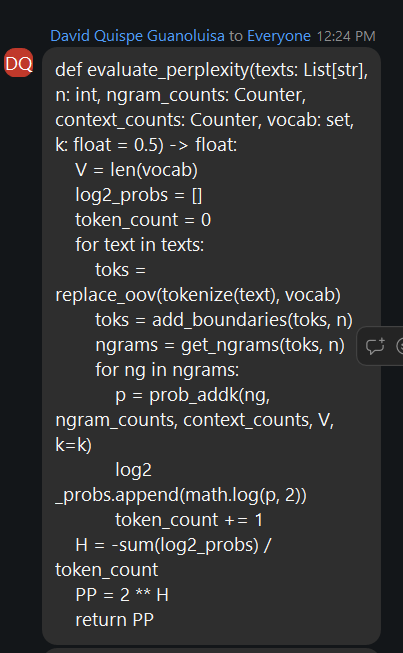


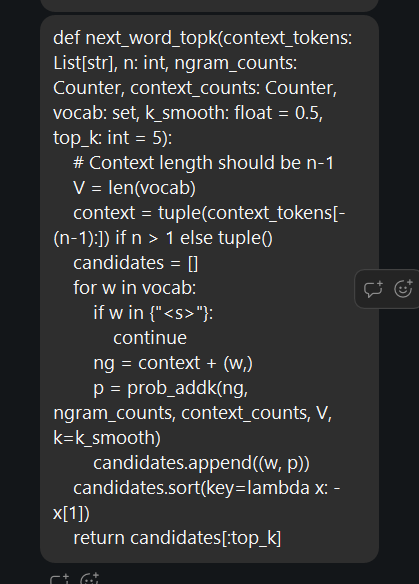